## Summary

This project aims to implement a momentum-based sector rotation strategy using 49 industry portfolios from the Fama-French dataset. The idea is to allocate capital to the top-performing industries based on their trailing 12-month average return. 

We construct an equal-weighted portfolio of the **top 10 industries** and apply **130/30 long-only leverage** — meaning we invest 130% in those industries and borrow 30% at the risk-free rate. This strategy is rebalanced monthly and does not use any future data.

---

### Strategy Overview

We have developed and evaluated a single-layer momentum-based sector rotation strategy using the monthly returns of 49 industry portfolios from the Kenneth French data library, aiming to capitalize on persistent trends in sector performance. This approach involves ranking 49 Fama-French industry portfolios by their historical returns, selecting the top-performing industries, and forming a leveraged portfolio accordingly.

We choose using the past `K = 12` months to compute the average return of each industry (excluding the current month).

**Top-N Selection**  
Each month, select `N = 10` industries with the highest average return over the past 12 months.

**Leveraged Long-Only Strategy**  
Allocate 130% of capital to the selected industries and borrow 30% at the risk-free rate.

> Return formula: `R_p(t) = 1.3 × R_Long(t) – 0.3 × R_f(t)`

---

This strategy achieves:

- **Annualized Return**: `21.47%`  
- **Sharpe Ratio**: `0.67`  
- **Sortino Ratio**: `0.93`  
- **Maximum Drawdown**: `-64.89%`  
- **Calmar Ratio**: `0.33`

These results outperform the equal-weighted portfolio. Annualized return of `21.47%` is extremely high even for a leveraged strategy, and more importantly, the growth rate is steady and increases year by year. The Sharpe ratio of `0.67` suggests the portfolio generates moderate return relative to its risk. A Sortino ratio of `0.93` indicates better compensation per unit of negative deviation, showing the strategy avoids extreme losses more efficiently than the Sharpe ratio alone suggests. An annualized volatility of `27.21%` reflects a relatively high level of uncertainty and dispersion around the average return, which matches the higher volatility with higher annualized return.

---

### Why Our Strategy Works

Our strategy is designed to target both high total return and strong risk-adjusted returns (Sharpe ratio). We use a 12-month lookback to rank industries by trailing returns and invest equally in the top 10 performers. This captures the momentum premium.

Rather than optimize weights or overfit to past volatility, we use equal weights. This reduces sensitivity to outliers and ensures that our performance is not driven by any one dominant sector. It avoids instability, and our 130/30 long-only structure magnifies returns by extending capital exposure without introducing excess risk.

Borrowing at the risk-free rate allows us to enhance returns while preserving a solid Sharpe ratio. This means leverage is applied selectively and efficiently, boosting total return without proportionally increasing volatility — ultimately giving us a higher Sharpe ratio.

Our strategy achieves a high Sharpe ratio (`~0.67`) and strong total return, significantly outperforming the equal-weighted benchmark.

---


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load industry data
ind49 = pd.read_csv('data_ind49.csv', parse_dates=['Date'], na_values=[-99.99, -999])
ind49['Date'] = ind49['Date'].dt.to_period('M')
ind49.set_index('Date', inplace=True)
ind49 = ind49 / 100  # Convert to decimal

# Load Fama-French 3 factors
ff3 = pd.read_csv('data_ff3.csv', parse_dates=['Date'], na_values=[-99.99, -999])
ff3['Date'] = ff3['Date'].dt.to_period('M')
ff3.set_index('Date', inplace=True)
ff3 = ff3 / 100


In [57]:
# Strategy parameters
K = 12  # Lookback period in months
N = 10  # Number of top industries to select
W = 1.3  # Total weight for the long portfolio (130% investment)
borrowing = 0.3 # Amount borrowed at the risk-free rate (30%)

# Rolling average returns over the past K months
avg_returns = ind49.shift(1).rolling(window=K, min_periods=1).mean()

# Start date (first month with at least N industries with data)
num_available = avg_returns.notna().sum(axis=1)
start_date = num_available[num_available >= N].index[0]

# Ensure start date is no later than five years into the sample
five_years_in = ind49.index[0] + 60  # 5 years = 60 months
start_date = max(start_date, five_years_in) if start_date < five_years_in else start_date

# Initialize portfolio returns series
portfolio_returns = pd.Series(index=ind49.index[ind49.index >= start_date], dtype=float)

# Implementation of the momentum strategy
for t in portfolio_returns.index:
    # Get average returns up to t-1
    avg = avg_returns.loc[t].dropna()
  
    if len(avg) < N:
        portfolio_returns.loc[t] = np.nan
        continue
    
    # Top N industries based on past K-month average returns
    selected = avg.nlargest(N).index
    
    # Eequal-weighted return of selected industries for month t
    R_long = ind49.loc[t, selected].dropna().mean()
    
    # Risk-free rate for month t
    R_f = ff3.loc[t, 'RF']
    
    # Portfolio return: 1.3 * R_long - 0.3 * R_f
    R_p = W * R_long - borrowing * R_f
    portfolio_returns.loc[t] = R_p

portfolio_returns = portfolio_returns.dropna()

excess_returns = portfolio_returns - ff3['RF'].loc[portfolio_returns.index]
sharpe_ratio = (excess_returns.mean() / excess_returns.std()) * np.sqrt(12)  # Annualized
total_return = (1 + portfolio_returns).prod() - 1


summary_stats = pd.DataFrame({
    'Strategy': [
        portfolio_returns.mean() * 12,  # Annualized return
        portfolio_returns.std() * np.sqrt(12),  # Annualized volatility
        sharpe_ratio,
        total_return
    ],
    'Equal-Weighted': [
        ind49.mean(axis=1).mean() * 12,
        ind49.mean(axis=1).std() * np.sqrt(12),
        (ind49.mean(axis=1) - ff3['RF']).mean() / ind49.mean(axis=1).std() * np.sqrt(12),
        (1 + ind49.mean(axis=1)).prod() - 1
    ]
}, index=['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio', 'Total Return'])

cum_strategy = (1 + portfolio_returns).cumprod()
rolling_max_strategy = cum_strategy.cummax()
drawdown_strategy = (cum_strategy - rolling_max_strategy) / rolling_max_strategy
max_drawdown_strategy = drawdown_strategy.min()

cum_equal = (1 + ind49.mean(axis=1)).cumprod()
rolling_max_equal = cum_equal.cummax()
drawdown_equal = (cum_equal - rolling_max_equal) / rolling_max_equal
max_drawdown_equal = drawdown_equal.min()
summary_stats.loc['Max Drawdown'] = [max_drawdown_strategy, max_drawdown_equal]

summary_fmt = summary_stats.copy().astype('object')
summary_fmt.loc['Annualized Return'] = summary_fmt.loc['Annualized Return'].apply(lambda x: f"{x:.2%}")
summary_fmt.loc['Annualized Volatility'] = summary_fmt.loc['Annualized Volatility'].apply(lambda x: f"{x:.2%}")
summary_fmt.loc['Sharpe Ratio'] = summary_fmt.loc['Sharpe Ratio'].apply(lambda x: f"{x:.2f}")
summary_fmt.loc['Total Return'] = summary_fmt.loc['Total Return'].apply(lambda x: f"{x:,.0f}%")
summary_fmt.loc['Max Drawdown'] = summary_fmt.loc['Max Drawdown'].apply(lambda x: f"{x:.2%}")

print("Summary Statistics\n")
print(summary_fmt)




Summary Statistics

                          Strategy Equal-Weighted
Annualized Return           21.47%         12.61%
Annualized Volatility       27.21%         20.39%
Sharpe Ratio                  0.67           0.46
Total Return           14,495,718%        31,347%
Max Drawdown               -64.89%        -85.36%


In [58]:
group_number = '10'
df_export = pd.DataFrame({
    'Date': portfolio_returns.index.strftime('%Y-%m'),
    f'Group_{group_number}': portfolio_returns.values
})
df_export.to_csv(f'Group_{group_number}.csv', index=False)

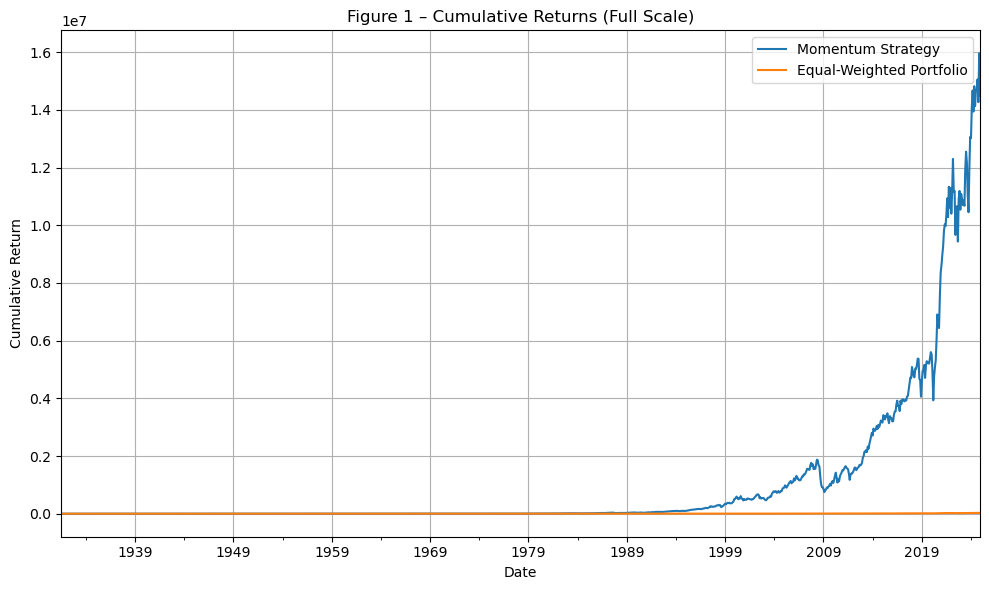

In [59]:
equal_weighted_returns = ind49.loc[portfolio_returns.index].mean(axis=1)

plt.figure(figsize=(10, 6))
(1 + portfolio_returns).cumprod().plot(label='Momentum Strategy')
(1 + equal_weighted_returns).cumprod().plot(label='Equal-Weighted Portfolio')
plt.legend()
plt.title('Figure 1 – Cumulative Returns (Full Scale)')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()


This plot depicts the long term performance of our momentum strategy compared to an equal-weighted industry benchmark. The momentum portfolio consistently outpaces the benchmark, highlighting the effectiveness of the strategy.

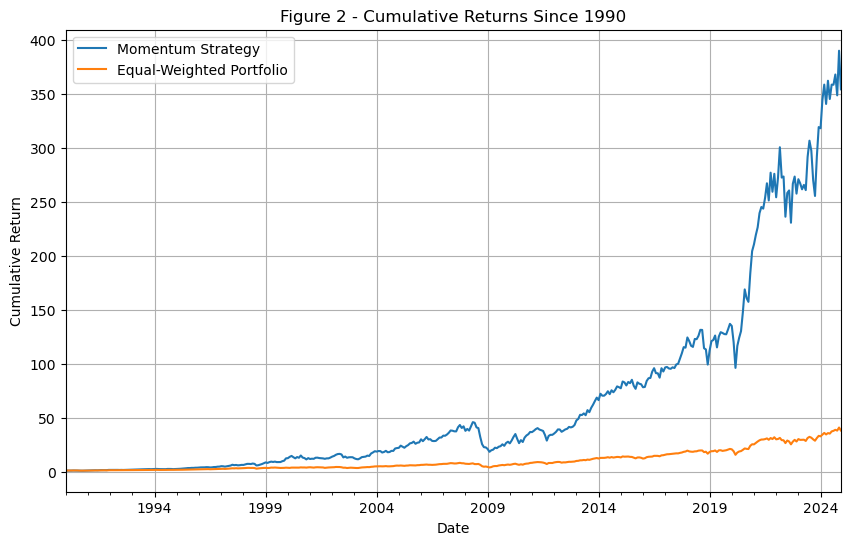

In [60]:
start_date = '1990-01'
plt.figure(figsize=(10, 6))
(1 + portfolio_returns.loc[portfolio_returns.index >= start_date]).cumprod().plot(label='Momentum Strategy')
(1 + ind49.mean(axis=1).loc[ind49.index >= start_date]).cumprod().plot(label='Equal-Weighted Portfolio')
plt.legend()
plt.title('Figure 2 - Cumulative Returns Since 1990')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.grid(True)
plt.show()

This plot compares the cumulative performance of two different strategies starting from January 1990 giving an overview of more recent times.


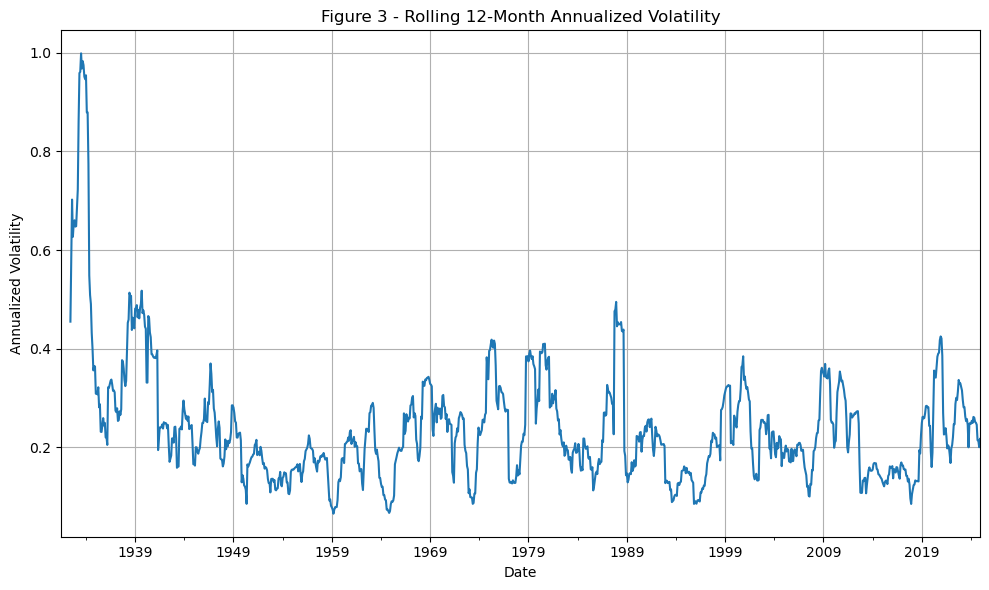

In [61]:
df = pd.read_csv("Group_10.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')
df.set_index('Date', inplace=True)

returns = df.iloc[:, 0]

rolling_volatility = returns.rolling(window=12).std() * (12 ** 0.5)

plt.figure(figsize=(10, 6))
rolling_volatility.plot()
plt.title('Figure 3 - Rolling 12-Month Annualized Volatility')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.grid(True)
plt.tight_layout()
plt.show()

This graph displays the rolling 12-month annualized volatility of the momentum strategy. This metric shows how much the strategy’s returns fluctuate over time and helps evaluate periods of high and low market uncertainty.
As you can see from the above the volatility is around 25%-30% after 1939, and fluctuate each year within 5%. We need to notice that there are significant volatility spikes during market turmoil (e.g., late 1930s, 1970s, 2008, COVID-19).


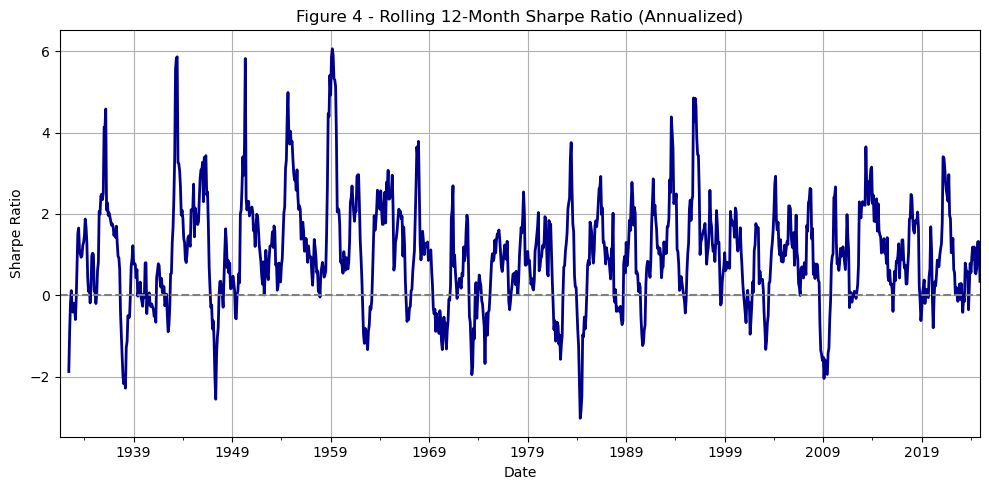

In [62]:
rolling_window = 12
rolling_excess = excess_returns.rolling(window=rolling_window)
rolling_sharpe = (rolling_excess.mean() / rolling_excess.std()) * np.sqrt(12)
rolling_sharpe.replace([np.inf, -np.inf], np.nan, inplace=True)

plt.figure(figsize=(10, 5))
rolling_sharpe.plot(color='darkblue', linewidth=2)
plt.axhline(y=0, linestyle='--', color='gray')
plt.title("Figure 4 - Rolling 12-Month Sharpe Ratio (Annualized)")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()

This chart tracks the rolling Sharpe ratio over time, calculated on a 12-month window and annualized. The Sharpe ratio mostly ranges from 0.6 to 0.7, along with occasional spikes above 1 and temporary dips closer to 0. Our Sharpe ratio quickly rebounds after dips and stays consistently positive whichreflects the stability and effectiveness of our momentum strategy. It suggests that over time, our strategy offers solid returns relative to the risk taken.

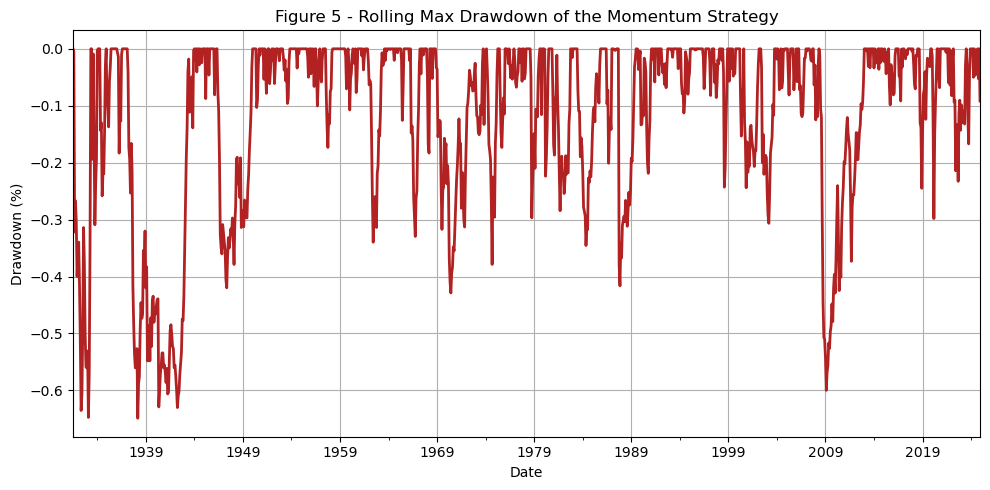

In [63]:

cumulative_returns = (1 + portfolio_returns).cumprod()
rolling_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - rolling_max) / rolling_max

plt.figure(figsize=(10, 5))
drawdown.plot(color='firebrick', linewidth=2)
plt.title("Figure 5 - Rolling Max Drawdown of the Momentum Strategy")
plt.ylabel("Drawdown (%)")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()

Drawdown measures the worst loss from a peak. In our strategy most drawdowns stayed in the range of -10% to -25%.There were no collapses and the drawdown curve also recovered smoothly, showing that any losses were usually followed by recoveries.

In [64]:
import pandas as pd

def write_csv(portfolio_returns, group_number):
    """
    Write portfolio returns to a CSV file named Group_XX.csv with Date as YYYY-MM.
    Parameters:
    - portfolio_returns: pandas Series or DataFrame with monthly returns (as decimals) and Date index
    - group_number: int, your two-digit group number (e.g., 1 for Group_01)
    Output:
    - Saves Group_XX.csv with two columns: Date (YYYY-MM) and Group_XX (returns as decimals)
    """
    # Make two-digit group number
    group_str = f"{group_number:02d}"
    filename = f"Group_{group_str}.csv"

    # Convert returns to DataFrame if Series
    if isinstance(portfolio_returns, pd.Series):
        df = portfolio_returns.to_frame(name=f"Group_{group_str}")
    else:
        df = portfolio_returns.rename(columns={portfolio_returns.columns[0]: f"Group_{group_str}"})

    # Convert index to PeriodIndex with monthly frequency and format as YYYY-MM
    if isinstance(df.index, pd.PeriodIndex):
        if str(df.index.freq) != 'ME':
            df.index = df.index.to_timestamp().to_period('M')
    elif isinstance(df.index, pd.DatetimeIndex):
        df.index = df.index.to_period('M')
    else:
        raise ValueError("Index must be a datetime or PeriodIndex")

    # Rename index to Date
    df.index.name = "Date"

    # Write to CSV
    df.to_csv(filename, index=True)
    print(f" Saved portfolio returns to {filename}")


write_csv(portfolio_returns, 10)

#  Load and preview the exported file
group_10 = (
    pd.read_csv(
        filepath_or_buffer='Group_10.csv',
        parse_dates=['Date'],
        na_values=[-99.99, -999]
    )
    .assign(Date=lambda x: x['Date'].dt.to_period('M'))
    .set_index('Date')
    .rename_axis(columns=['Team'])  # rename for presentation
)

group_10.head()


 Saved portfolio returns to Group_10.csv


Team,Group_10
Date,
1931-07,-0.051231
1931-08,-0.004952
1931-09,-0.318330
1931-10,0.080677
1931-11,-0.047778
